In [1]:
from torch.utils.data import Dataset
import torch
import SimpleITK as sitk
import os
import numpy as np
import matplotlib.pyplot as plt
from networks_update import *

class Segmentation3DDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform  # Optional (e.g., normalization, crop)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = sitk.ReadImage(self.image_paths[idx])
        image = sitk.GetArrayFromImage(image)

        # Add channel dimension if needed (C x D x H x W)
        if image.ndim == 3:
            image = np.expand_dims(image, axis=0)
        
        if self.transform:
            image = self.transform(image)

        return torch.from_numpy(image).to(torch.float)


In [ ]:
class Encoder_VAE(nn.Module):
    def __init__(self, n_downsample, n_res, input_dim, dim, norm, activ, pad_type):
        super(Encoder_VAE, self).__init__()
        self.model = []
        self.model += [Conv3dBlock(input_dim, dim, 7, 1, 3, norm=norm, activation=activ, pad_type=pad_type)]
        # downsampling blocks
        for i in range(n_downsample):
            self.model += [Conv3dBlock(dim, 2 * dim, 4, 2, 1, norm=norm, activation=activ, pad_type=pad_type)]
            dim *= 2
        # residual blocks
        self.model += [ResBlocks(n_res, dim, norm=norm, activation=activ, pad_type=pad_type)]

        latent_dim = 1024
        flattened_dim = 16*30*30*32

        self.model += [nn.Flatten(), nn.Linear(flattened_dim, latent_dim), nn.LayerNorm(latent_dim), nn.ReLU()]

        self.output_dim = dim

        # NOTE: dim might be incorrect here??
        self.inplace = nn.Linear(latent_dim, latent_dim)

        self.model = nn.Sequential(*self.model)

    def forward(self, x):
        out = self.model(x)
        means = self.inplace(out)
        log_vars = self.inplace(out) # why was it called log vars? Probs cuz of how it's used in KL divergence
        return means, log_vars
    

import torch.nn as nn

class Reshape(nn.Module):
    def __init__(self):
        super().__init__()
        self.shape = (16, 32, 30, 30)  # e.g., (-1, 512) or (batch_size, channels, height, width)

    def forward(self, x):
        return x.reshape(x.size(0), *self.shape)  # keeps batch dim intact

class Decoder_VAE(nn.Module):
    def __init__(self, n_upsample, n_res, dim, output_dim, res_norm='in', activ='relu', pad_type='zero'): # NOTE: updated normalization to in to not have to compute weight and bias externally
        super(Decoder_VAE, self).__init__()

        self.model = []

        latent_dim = 1024
        flattened_dim = 16*30*30*32

        self.model += [nn.Linear(latent_dim, flattened_dim), nn.LayerNorm(flattened_dim), nn.ReLU(), Reshape()]
        
        # AdaIN residual blocks # NOTE: changed!!
        self.model += [ResBlocks(n_res, dim, res_norm, activ, pad_type=pad_type)]
        # upsampling blocks
        for i in range(n_upsample):
            self.model += [nn.Upsample(scale_factor=2),
                           Conv3dBlock(dim, dim // 2, 5, 1, 2, norm='ln', activation=activ, pad_type=pad_type)] # NOTE: could update to instance norm since only a batch size of 2 -> don't want to normalize over full layer??
            dim //= 2
        # use reflection padding in the last conv layer
        self.model += [Conv3dBlock(dim, output_dim, 7, 1, 3, norm='none', activation='none', pad_type=pad_type)] 
        self.model = nn.Sequential(*self.model)

    def forward(self, x):
        return self.model(x)

In [3]:
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from networks_update import Encoder, Decoder

# Dataset path
train_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/train/images/"
train_paths = [train_folder + file_name for file_name in os.listdir(train_folder)]

# Create dataset and dataloader
train_dataset = Segmentation3DDataset(image_paths=train_paths)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# Initialize model
encoder = Encoder_VAE(n_downsample=2, n_res=4, input_dim=1, dim=4, norm='in', activ='relu', pad_type='zero') # encodes to 32 dim??
decoder = Decoder_VAE(n_upsample=2, n_res=4, dim=encoder.output_dim, output_dim=4)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder.to(device)
decoder.to(device)

# Loss function for VAE
def loss_func(imgs, recons, means, log_vars):
    criterion = nn.CrossEntropyLoss()
    recon = criterion(recons, imgs) # computes average per voxel (in CVAE they use this instead to sum over all voxels)

    BS = 4
    num_voxels = 1843200
    beta = 10
    KLD = (-0.5*torch.sum(1 + log_vars - means.pow(2) - log_vars.exp())) / num_voxels*BS

    return recon + beta*KLD

def reparameterization(means, log_vars):
    # move random vars sampled from a normal dist to size log_vars to device
    epsilon = torch.randn_like(log_vars).to(device) 
    z = means + log_vars*epsilon
    return z

optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-4)


In [4]:
num_epochs = 50
save_loss = []

for epoch in range(num_epochs):
    encoder.train()
    decoder.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)  # (B, C, D, H, W)

        # Forward pass
        means, log_vars = encoder(batch)

        # get latent vectors - sampled from learned dists
        z = reparameterization(means, log_vars)

        recon = decoder(z)

        # Compute loss
        loss = loss_func(batch.squeeze(1).long(), recon, means, log_vars)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss / len(train_loader):.4f}")
    save_loss.append(total_loss / len(train_loader))

# ~30s per epoch

RuntimeError: mat1 and mat2 shapes cannot be multiplied (4x1100 and 1200x460800)

In [ ]:
# save a checkpoint
checkpoint = {
    'epoch': epoch,
    'encoder_state_dict': encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': total_loss
}

torch.save(checkpoint, './VAE_prelim_tests/train_1_mouse_epoch_50.pth')

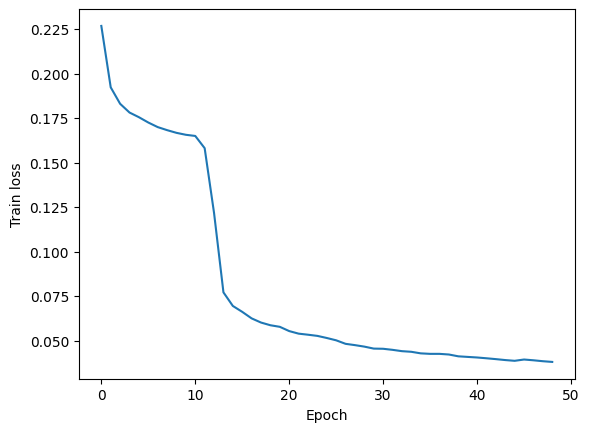

In [ ]:
# plot loss
plt.figure()
plt.plot(save_loss[1:])
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.show()

In [ ]:
checkpoint = torch.load('./encoder_decoder_test/checkpoint_mouse_cross_entropy_4_chan_bs_4.pth', map_location=device)

encoder.load_state_dict(checkpoint['encoder_state_dict'])
decoder.load_state_dict(checkpoint['decoder_state_dict'])

RuntimeError: Error(s) in loading state_dict for Encoder_VAE:
	Missing key(s) in state_dict: "inplace.weight", "inplace.bias", "model.5.weight", "model.5.bias", "model.6.weight", "model.6.bias". 
	size mismatch for model.0.conv.weight: copying a param with shape torch.Size([32, 1, 7, 7, 7]) from checkpoint, the shape in current model is torch.Size([4, 1, 7, 7, 7]).
	size mismatch for model.0.conv.bias: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([4]).
	size mismatch for model.1.conv.weight: copying a param with shape torch.Size([64, 32, 4, 4, 4]) from checkpoint, the shape in current model is torch.Size([8, 4, 4, 4, 4]).
	size mismatch for model.1.conv.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([8]).
	size mismatch for model.2.conv.weight: copying a param with shape torch.Size([128, 64, 4, 4, 4]) from checkpoint, the shape in current model is torch.Size([16, 8, 4, 

In [ ]:
# Evaluate model performance
# Dataset path
test_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/test/images/"
test_paths = [test_folder + file_name for file_name in os.listdir(test_folder)]

# Create dataset and dataloader
test_dataset = Segmentation3DDataset(image_paths=test_paths)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

encoder.eval()
decoder.eval()

save_latent_e = []
save_recon = []
test_loss = 0


for batch in test_loader:
    batch = batch.to(device)  # (B, C, D, H, W)

    # Forward pass
    means, log_vars = encoder(batch)

    # get latent vectors - sampled from learned dists
    z = reparameterization(means, log_vars)

    recon = decoder(z)

    # Compute loss
    #loss = criterion(recon, batch.squeeze(1).to(torch.long))
    #test_loss += loss.item()

    recon = torch.argmax(recon, dim=1)

    #save_latent_e.append(z.detach().cpu())
    save_recon.append(recon.detach().cpu())


    


In [ ]:
def plot_img(img_arr, slice_idx, title="", cmap="gray"):
    plt.figure(figsize=(3,3))
    plt.imshow(img_arr[slice_idx, :, :], cmap)
    plt.title(title)
    plt.colorbar()
    plt.show()

test loss: 0.0
truth shape (128, 120, 120)
recon shape (128, 120, 120)


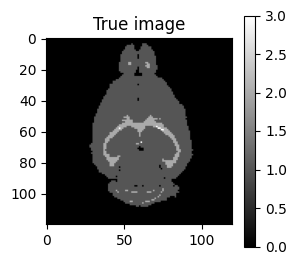

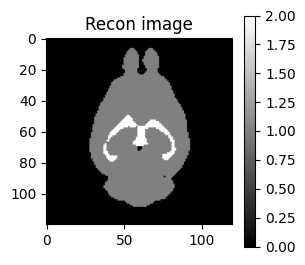

truth shape (128, 120, 120)
recon shape (128, 120, 120)


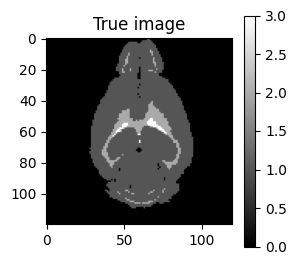

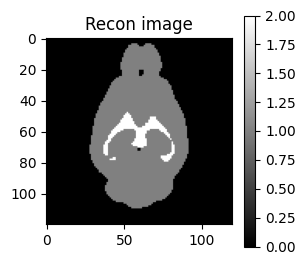

truth shape (128, 120, 120)
recon shape (128, 120, 120)


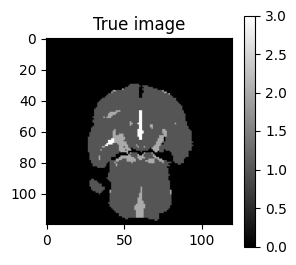

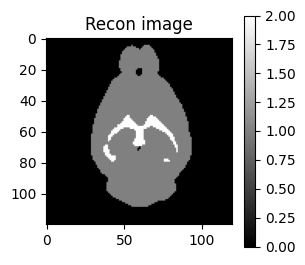

truth shape (128, 120, 120)
recon shape (128, 120, 120)


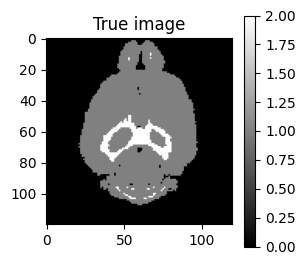

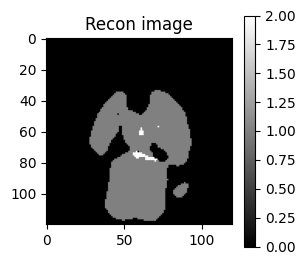

truth shape (128, 120, 120)
recon shape (128, 120, 120)


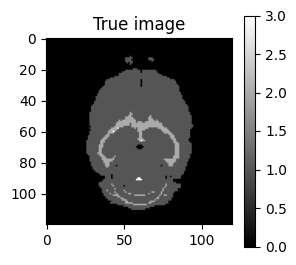

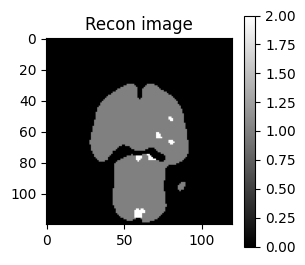

In [ ]:
# plot a original versus recon image
print("test loss:", test_loss / len(test_loader))
#print("latent shape:", np.array(save_latent_e[0]).shape)

for idx in range(5):
    truth_img = sitk.GetArrayFromImage(sitk.ReadImage(test_paths[idx]))
    recon_img = np.array(save_recon[idx]).squeeze()

    print("truth shape", truth_img.shape)
    print("recon shape", recon_img.shape)

    slice_idx = 50
    plot_img(truth_img, slice_idx, "True image")
    plot_img(recon_img, slice_idx, "Recon image")

Evaluate trained encoder/decoder preformance

In [ ]:


# plot loss
plt.figure()
plt.plot(save_loss)
plt.plot(save_loss)
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.show()

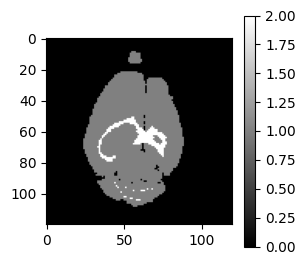

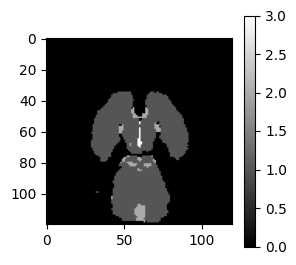

In [ ]:
idx = 2
train_save_folder = "./save_models/mouse_train_1/"
epoch = 190
slice_idx = 80

test_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/train/images/"
test_paths = [test_folder + file_name for file_name in os.listdir(test_folder)]


truth_img = sitk.GetArrayFromImage(sitk.ReadImage(test_paths[idx]))
recon_img = sitk.GetArrayFromImage(sitk.ReadImage(train_save_folder + "test_images/img_" + str(idx) + "_epoch_" + str(epoch) + ".nii"))

plot_img(truth_img, slice_idx)
plot_img(recon_img, slice_idx)
